# Phase 3: Text Classification (Classic)

**Dataset:** `szzs1693/intro-nlp-thai-news` — 3 categories: `politics`, `economics`, `social`

In [1]:
# Setup Thai font for matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

!wget -q -O thsarabunnew-webfont.ttf https://github.com/PyThaiNLP/prachathai-67k/raw/master/thsarabunnew-webfont.ttf

fm.fontManager.addfont("thsarabunnew-webfont.ttf")
plt.rc('font', family='TH Sarabun New')

## 1. Load Dataset

In [2]:
from datasets import load_dataset
ds = load_dataset("szzs1693/intro-nlp-thai-news")
df = ds["train"].to_pandas()
df.head()

,url,date,title,body_text,category,source
0,https://prachatai.com/print/2575,2005-02-03 02:09:00,ปากคำแก๊งหน้าดารา : อันธพาลกวนเมือง หรือ?,คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้ง...,social,prachathai
1,https://prachatai.com/print/4921,2005-07-16 10:17:00,วิษณุแจงออก พ.ร.ก.. ฉุกเฉินเพื่อบูรณาการกฎหมาย,[1]\nประชาไท15 ก.ค. 2548 นายวิษณุ เครืองาม รอ...,politics,prachathai
2,https://prachatai.com/print/4923,2005-07-16 10:18:00,คำอธิบายพระราชกำหนดบริหารราชการในสถานการณ์ฉุกเ...,ภายหลังการประชุมคณะรัฐนตรีนัดพิเศษ นายวิษณุ เค...,politics,prachathai
3,https://prachatai.com/print/4939,2005-07-18 01:49:00,อนุกรรมการสมานฉันท์ฯถกพรก.ฉุกเฉิน,นายอับดุลอาซิซ ตาเดอินทร์ รองนายกสมาคมยุวมุสลิ...,politics,prachathai
4,https://prachatai.com/print/4945,2005-07-18 16:26:00,"โพลระบุ ""คน 3 จว.ใต้-กทม."" หนุนรัฐออกกม.สถานกา...",สำนักวิจัยเอแบคโพลล์ มหาวิทยาลัยอัสสัมชัญ ได้ส...,politics,prachathai


In [3]:
print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (6603, 6)

Null values:
url          0
date         0
title        0
body_text    0
category     0
source       0
dtype: int64

Dtypes:
url                     str
date         datetime64[us]
title                   str
body_text               str
category                str
source                  str
dtype: object


## 2. Preprocessing

ภาษาไทยไม่มีช่องว่างระหว่างคำ ต้องแบ่งคำ (word segmentation) ด้วยตัวเองก่อนส่งเข้า library อื่น ๆ ไปใช้งาน

ใช้ `pythainlp` `newmm` engine (dictionary-based maximum matching), แล้วเชื่อมด้วยช่องวาง (space) เพื่อให้ `TfidfVectorizer` เข้าใจและแบ่งคำได้

In [4]:
%pip install pythainlp

Note: you may need to restart the kernel to use updated packages.


In [5]:
from pythainlp.tokenize import word_tokenize

def tokenize(text: str) -> str:
    tokens = word_tokenize(text, engine="newmm", keep_whitespace=False)
    return " ".join(tokens)

In [6]:
from tqdm import tqdm
# This cell is slow (~5–10 min depending on hardware). Run once and proceed.
tqdm.pandas(desc="Tokenizing")
df["tokenized_text"] = df["body_text"].progress_apply(tokenize)

Tokenizing: 100%|██████████████████████████████████████████████████| 6603/6603 [00:46<00:00, 142.75it/s]


In [7]:
# Sanity check — compare raw vs tokenized for one article
sample = df.iloc[0]
print("=== RAW (first 300 chars) ===")
print(sample["body_text"][:300])
print("\n=== TOKENIZED (first 300 chars) ===")
print(sample["tokenized_text"][:300])

=== RAW (first 300 chars) ===
คดีซามูไรผมแดงครั้งนั้น กลายเป็นข่าวใหญ่โตทั้งหนังสือพิมพ์ วิทยุและทีวี ทำให้คนรู้จักกลุ่มของพวกเราไปทั้งประเทศ ผมไม่อยากพูดถึง เพราะมันเป็นความผิดที่ทำให้เราถูกเกลียดชัง ถูกจับจ้องมองทั้งจากตำรวจและจากแหล่งสื่อต่างๆ
คดีที่เกิดขึ้นหลายครั้งต่อมา ทั้งสื่อ ตำรวจ และสังคมต่างพากันประโคมข่าวว่า เป็นกลุ่

=== TOKENIZED (first 300 chars) ===
คดี ซามูไร ผม แดง ครั้งนั้น กลาย เป็นข่าว ใหญ่โต ทั้ง หนังสือพิมพ์ วิทยุ และ ทีวี ทำให้ คนรู้จัก กลุ่ม ของ พวกเรา ไป ทั้ง ประเทศ ผม ไม่ อยาก พูดถึง เพราะ มัน เป็นความ ผิดที่ ทำให้ เรา ถูก เกลียดชัง ถูกจับ จ้องมอง ทั้ง จาก ตำรวจ และ จาก แหล่ง สื่อ ต่างๆ 
 คดี ที่ เกิดขึ้น หลาย ครั้งต่อมา ทั้ง สื่อ ตำ


## 3. Train / Validation / Test Split

We use a **70 / 15 / 15** stratified split to preserve class balance across all three sets.

**3.1 Stratified Train/Test Split (Category + Source)**

In [8]:
# สร้าง composite key เพื่อ stratify ทั้ง category และ source
df["stratify_key"] = df["category"] + "_" + df["source"]

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["stratify_key"],
    random_state=42
)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 5282
Test size: 1321


In [9]:
train_df, val_df = train_test_split(
    train_df,
    test_size=0.176,  # ทำให้ final val ≈ 15%
    stratify=train_df["stratify_key"],
    random_state=42
)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4352
Validation: 930
Test: 1321


**3.2 Prepare X, y**

In [10]:
X_train = train_df["tokenized_text"]
X_test = test_df["tokenized_text"]

X_val = val_df["tokenized_text"]
y_val = val_df["category"]

y_train = train_df["category"]
y_test = test_df["category"]

**3.3 TF-IDF Feature**

- TF-IDF เป็นการ Preprocess feature แบบนึง
- ใน Data **Train** ให้เรา `fit_transform` เพื่อให้โมเดลเรียนรู้ความแตกต่างจาก feature ของ data นั้น  
- ใน Data อื่น ๆ เช่น **Validate** หรือ **Test** ให้เรา `transform` เท่านั้น เราจะไม่ fit กับอันอื่นอีก

Key parameters:
- `max_features=50000` — caps vocabulary size to the top 50k terms by frequency
- `sublinear_tf=True` — applies log normalization to term frequency, reducing the dominance of very frequent words
- `min_df=5` — excludes terms that appear in fewer than 5 documents, removing rare/noisy words and reducing vocabulary size

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=50_000, sublinear_tf=True)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"Vocabulary size: {len(vectorizer.vocabulary_):,}")
print(f"Train matrix shape: {X_train_tfidf.shape}")

Vocabulary size: 31,127
Train matrix shape: (4352, 31127)


**3.4 Train Naive Bayes**

In [12]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

**3.5 Train Logistic Regression**

In [13]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

**3.6 Evaluation**

In [14]:
from sklearn.metrics import classification_report

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb))

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lr))

=== Naive Bayes ===
              precision    recall  f1-score   support

   economics       0.74      0.90      0.81       441
    politics       0.79      0.83      0.81       440
      social       0.84      0.62      0.71       440

    accuracy                           0.78      1321
   macro avg       0.79      0.78      0.78      1321
weighted avg       0.79      0.78      0.78      1321

=== Logistic Regression ===
              precision    recall  f1-score   support

   economics       0.85      0.84      0.84       441
    politics       0.87      0.80      0.83       440
      social       0.77      0.84      0.80       440

    accuracy                           0.83      1321
   macro avg       0.83      0.83      0.83      1321
weighted avg       0.83      0.83      0.83      1321



**3.7 Confusion Matrix**

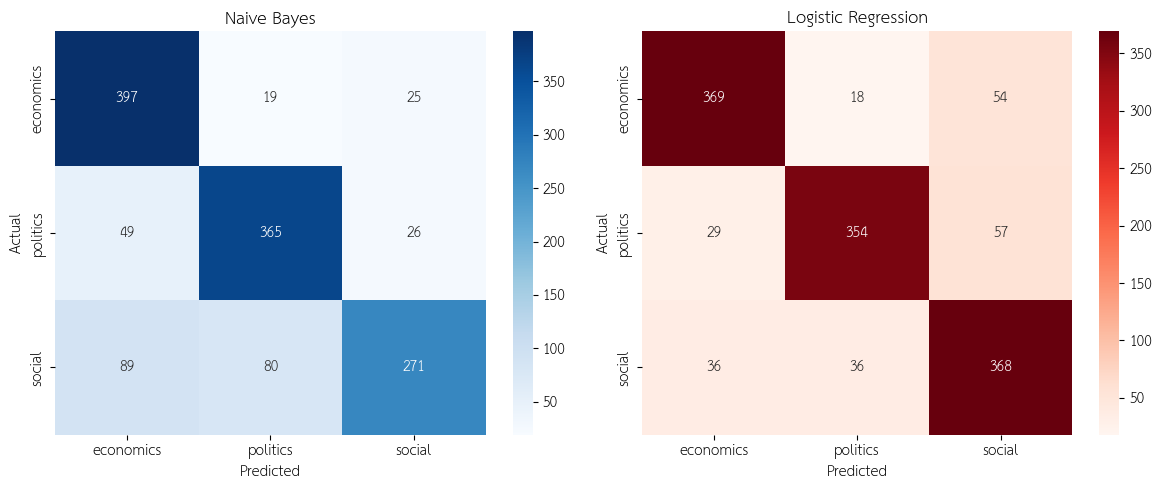

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

labels = sorted(y_test.unique())

cm_nb = confusion_matrix(y_test, y_pred_nb, labels=labels)
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Naive Bayes
sns.heatmap(cm_nb,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[0])
axes[0].set_title("Naive Bayes")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Logistic Regression
sns.heatmap(cm_lr,
            annot=True,
            fmt="d",
            cmap="Reds",
            xticklabels=labels,
            yticklabels=labels,
            ax=axes[1])
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

**3.8 กราฟเปรียบเทียบ**

**Note** F1 Macro คือ ค่า F1-score ที่คำนวณแยกทีละ class
แล้วเอามา **เฉลี่ยแบบไม่ถ่วงน้ำหนัก** ที่กัน Class Imbalance ถ้า dataset ไม่สมดุล

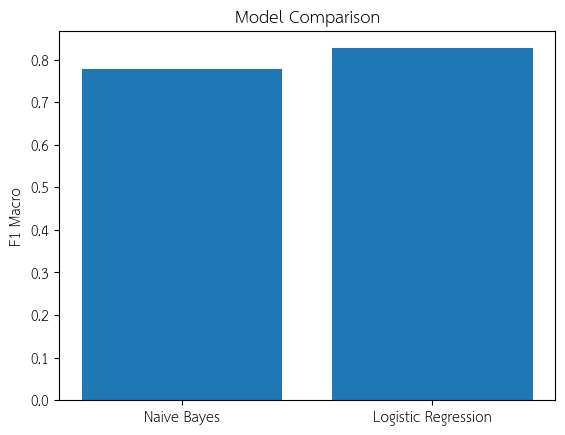

In [16]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

f1_nb = f1_score(y_test, y_pred_nb, average="macro")
f1_lr = f1_score(y_test, y_pred_lr, average="macro")

models = ["Naive Bayes", "Logistic Regression"]
scores = [f1_nb, f1_lr]

plt.bar(models, scores)
plt.ylabel("F1 Macro")
plt.title("Model Comparison")
plt.show()

**3.9 F1 แยกตาม Source**

In [17]:
test_df["pred_nb"] = y_pred_nb
test_df["pred_lr"] = y_pred_lr

from sklearn.metrics import f1_score

for src in test_df["source"].unique():
    subset = test_df[test_df["source"] == src]

    f1_nb_src = f1_score(subset["category"], subset["pred_nb"], average="macro")
    f1_lr_src = f1_score(subset["category"], subset["pred_lr"], average="macro")

    print(f"\nSource: {src}")
    print("NB F1:", f1_nb_src)
    print("LR F1:", f1_lr_src)


Source: prachathai
NB F1: 0.7610007732219706
LR F1: 0.8164510652477369

Source: thaipbs
NB F1: 0.8514723761586559
LR F1: 0.8703759613007739
